# Predicting Protein Prediction

Consider as starting point for this exercise a UCI Protein Structure. The dataset comes from the Critical Assessment of protein Structure Prediction experiments (CASP), which is a recurrent (biannual) initiative to predict protein structure from experimental data.

The dataset consists of roughly 45k entries with nine features and one target. 

The features essentially are calculated physicochemical descriptors:
- F1: Total surface area (Approximate exposed surface of the protein)
- F2: Non-polar exposed area (Hydrophobic surface)
- F3: Fraction of exposed nonpolar area (Ratio of hydrophobic and total surface)
- F4: Residue surface exposure (How much amino acids are exposed)
- F5: Secondary structure agreement (Measures consistency with expected structures (α-helices, β-sheets))
- F6: Pairwise distance features (Encodes distances between residues)
- F7: Compactness / packing (How tightly folded the protein is)
- F8: Structural energy-related feature (Proxy for physical plausibility)
- F9: Additional geometric descriptor (Captures global structure properties)

The target is the RMSD (Root Mean Squared Deviation) that describes the deviation of the predicted from the true protein structure. 

The aim of the exercise is to build a model to predict how accurate predicted structures would be based on calculated descriptors.

#### Tasks:
1) The data is somewhat abstract. Inspect it to see what can be expected of a potential model.
2) Create feature matrix and target vector.
3) Choose one Regression ML model, build it and optimise (consider scaling if the model class needs it)
4) Take note of the training and test time for your model (approximation is enough)
5) Whatever model you end up using, try to optimise for accuracy and minimal overfitting, use **MSE** for evaluating your model!
6) Respond to the discussion points.

#### Note:
Feel free in your choice in model class, everything covered in the course so far is on the table. You don't need to compare different ones, we will do that with the compiled results of all assignments.

In [1]:
# complete imports if needed for your solution
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader

Load and investigate the data

In [2]:
df = pd.read_csv("CASP.csv")
df.head()

,RMSD,F1,F2,F3,F4,F5,F6,F7,F8,F9
0,17.284,13558.30,4305.35,0.31754,162.1730,1.872791e+06,215.3590,4287.87,102,27.0302
1,6.021,6191.96,1623.16,0.26213,53.3894,8.034467e+05,87.2024,3328.91,39,38.5468
2,9.275,7725.98,1726.28,0.22343,67.2887,1.075648e+06,81.7913,2981.04,29,38.8119
3,15.851,8424.58,2368.25,0.28111,67.8325,1.210472e+06,109.4390,3248.22,70,39.0651
4,7.962,7460.84,1736.94,0.23280,52.4123,1.021020e+06,94.5234,2814.42,41,39.9147


Build feature matrix and target vector. Add scaling if needed for your model.

In [3]:
X = df.drop("RMSD", axis=1)
y = df["RMSD"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

Choose a Regression model, build, train and optimise

MSE on training set: 0.011403666288541435
MSE on test set: 25.426743740378306


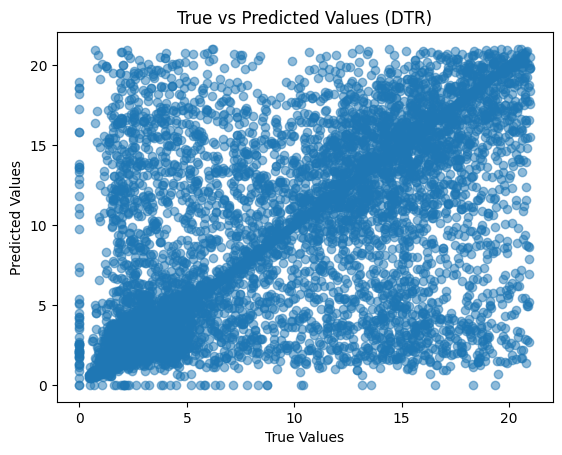

In [4]:
DTR = DecisionTreeRegressor(random_state=42)
DTR.fit(X_train, y_train)
y_test_pred_dtr = DTR.predict(X_test)
y_train_pred_dtr = DTR.predict(X_train)

print("MSE on training set:", mean_squared_error(y_train, y_train_pred_dtr))
print("MSE on test set:", mean_squared_error(y_test, y_test_pred_dtr))

plt.scatter(y_test, y_test_pred_dtr, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (DTR)")
plt.show()

MSE on training set: 1.7369556814240625
MSE on test set: 12.586083317004887


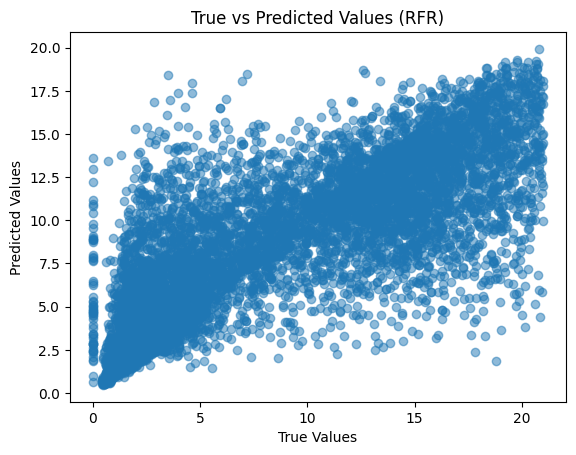

In [5]:
RFR = RandomForestRegressor(n_estimators=100, random_state=42)
RFR.fit(X_train, y_train)
y_test_pred_rfr = RFR.predict(X_test)
y_train_pred_rfr = RFR.predict(X_train)

print("MSE on training set:", mean_squared_error(y_train, y_train_pred_rfr))
print("MSE on test set:", mean_squared_error(y_test, y_test_pred_rfr))

plt.scatter(y_test, y_test_pred_rfr, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (RFR)")
plt.show()

MSE on training set: 23.376662614575277
MSE on test set: 24.29183549847823


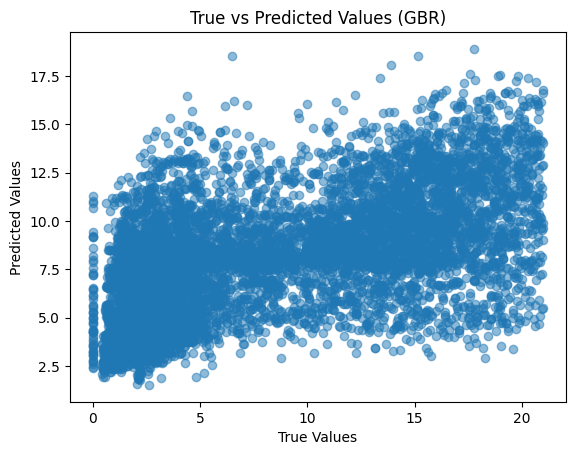

In [6]:
GBR = GradientBoostingRegressor(n_estimators=50, random_state=42)
GBR.fit(X_train, y_train)
y_test_pred_gbr = GBR.predict(X_test)
y_train_pred_gbr = GBR.predict(X_train)

print("MSE on training set:", mean_squared_error(y_train, y_train_pred_gbr))
print("MSE on test set:", mean_squared_error(y_test, y_test_pred_gbr))

plt.scatter(y_test, y_test_pred_gbr, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (GBR)")
plt.show()

MSE on training set: 26.72128473662127
MSE on test set: 27.461025209662676


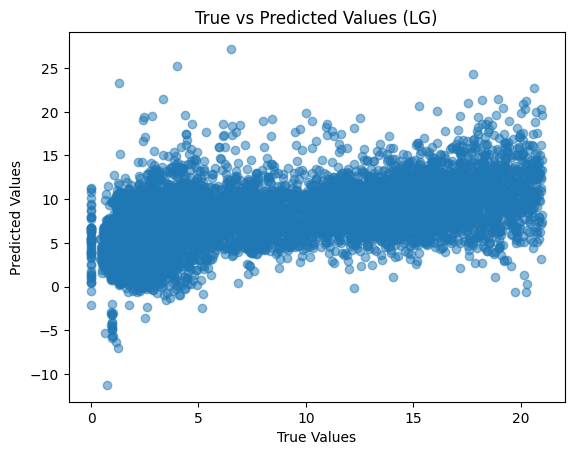

In [7]:
LG = LinearRegression()
LG.fit(X_train, y_train)
y_test_pred_lg = LG.predict(X_test)
y_train_pred_lg = LG.predict(X_train)

print("MSE on training set:", mean_squared_error(y_train, y_train_pred_lg))
print("MSE on test set:", mean_squared_error(y_test, y_test_pred_lg))

plt.scatter(y_test, y_test_pred_lg, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values (LG)")
plt.show()

In [8]:
class MyDataFromDF(Dataset):
    def __init__(self, X, y):
        # features provided as Dataframes converted
        self.X = torch.tensor(    
            X.to_numpy(), 
            dtype=torch.float32 # optionally include a datatype
            ) 
        
        # targets provided as Dataframes
        self.y = torch.tensor( 
            y.to_numpy(),
            dtype=torch.float32 # optionally include a datatype
            )            

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]   # always return (features, target)

In [9]:
X = df.drop("RMSD", axis=1)
y = df["RMSD"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

train_dataset = MyDataFromDF(X_train, y_train)
test_dataset  = MyDataFromDF(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [10]:
class RegressionNN(nn.Module):
    # define the layers
    def __init__(self, input_size, hidden_size, output_size):
        super(RegressionNN, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)  # input layer with width = length of the feature set
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, int(hidden_size/2))
        self.fc4 = nn.Linear(int(hidden_size/2), output_size)  # output layer
    
    # Define how the data flows through the layers
    def forward(self, x):            # forward pass
        x = torch.relu(self.fc1(x))  # ReLU activation function for input layer
        x = torch.relu(self.fc2(x))  # ReLU activation function for hidden layer
        x = torch.relu(self.fc3(x))  # ReLU activation function for hidden layer
        x = self.fc4(x)   # no activation function for the output layer (because it is a regresion model!)
        return x

In [11]:
# Hyperparameters
input_size = X_train.shape[1]
hidden_size = 16
output_size = 1

learning_rate = 0.0001
weight_decay = 0.00

# Number of training iterations
num_epochs = 100

In [12]:
import torch.optim as optim
model = RegressionNN(input_size, hidden_size, output_size)
# model = RegressionNN(input_size, hidden_size, output_size, drop_out).to(device)

criterion = nn.MSELoss()  # loss function defined;

optimizer = optim.AdamW(model.parameters(), learning_rate, weight_decay=weight_decay) # gradient descent method based on average and squares of gradient

In [13]:
# batched training
for epoch in range(num_epochs):

    model.train()
    total_loss = 0
    total_samples = 0

    for data, targets in train_loader:
        data = data.float()
        targets = targets.float().unsqueeze(1)  # add an extra dimension to targets to match output shape
        # data = data.to(device)
        # targets = targets.to(device)

        outputs = model(data.to(torch.float32))

        loss = criterion(outputs, targets)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # accumulate loss over batches
        batch_size = data.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    avg_loss = total_loss / total_samples

    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{num_epochs}], Loss: {avg_loss:.4f}')

Epoch [10/100], Loss: 63.8943
Epoch [20/100], Loss: 65.3336
Epoch [30/100], Loss: 72.4234
Epoch [40/100], Loss: 61.6335
Epoch [50/100], Loss: 70.2322
Epoch [60/100], Loss: 64.5807
Epoch [70/100], Loss: 64.7712
Epoch [80/100], Loss: 56.5726
Epoch [90/100], Loss: 58.8080
Epoch [100/100], Loss: 57.2285


In [16]:
# Evaluate the model
model.eval()  # set model to eval mode (e.g. no dropout)

all_preds = []
all_targets = []

total_samples = 0
total_loss = 0

criterion = nn.MSELoss()

with torch.no_grad():
    for data, targets in test_loader:
        data = data
        targets = targets
        # data = data.to(device)
        # targets = targets.to(device)

        outputs = model(data.to(torch.float32))
        loss = criterion(outputs, targets)

        # accumulate loss over batches
        batch_size = data.size(0)
        total_loss += loss.item() * batch_size # multiply by batch size to 
        total_samples += targets.size(0)
        
        # Predictions
        all_preds.extend(outputs.cpu().tolist()) # cpu() moves the tensor to cpu (if on gpu), tolist converts it to python list
        all_targets.extend(targets.cpu().tolist())

avg_loss = total_loss / total_samples

print(f"Average test Loss: {avg_loss:.4f}")


Average test Loss: 48.5607


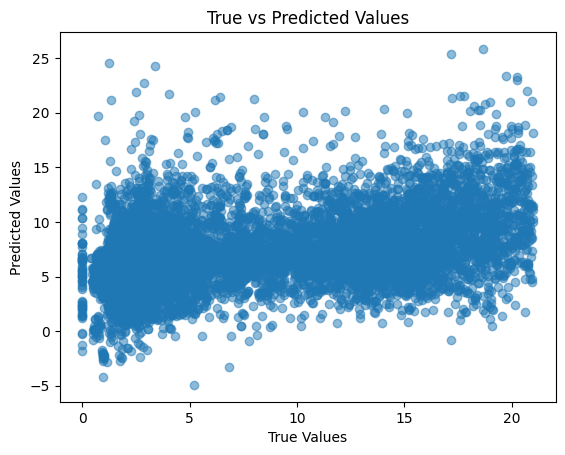

In [17]:
plt.scatter(all_targets, all_preds, alpha=0.5)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("True vs Predicted Values")
plt.show()

Evaluate your best model (MSE). Take note of training and test time (approximate).

#### Discussion points
1) Discuss your choice of model class.
- I chose most of the regression models which we have used before.
2) How did you optimise your model? How did the best model perform?
- The best model was the random forest regressor, it was optimized by changing the number of estimators which did not make much of a difference.
3) How much time was needed for training the model and evaluations (approximation is enough)?
- The random forest did not take too long (20 seconds), longer than most of the other model however. The NN took the longest amount of time both computationally and building it, the optimization also took really long and ended up being really bad.
4) What limitations or shortcomings did you identify? What would be ideas to remedy or circumvent them?
- One limitation for the random forest was that there were not many parameters to tune, I could probably change more but I dont know how. Limitation for the NN was the fact that it would keep getting stuck at a minimum where it just uses the mean value of all target values as the predicted value for all of the targets, I tried to fix this for a decent amount of time, but it never got any better unless I made the model with a lower hidden size which would just not get to that minimum but at the same time, the MSE would be larger.
5) In all its abstraction, what do the predictions of your model tell you?
- From the plots, we can see that the RMSDs can be somewhat accurately predicted from the descriptors, but that it becomes harder to predict for very low and very high RMSDs.